<a href="{{ colab_base_laboratorios }}/Laboratorio_10_nn_keras__V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 10: Red neuronal con keras



| Función de activación | Ventajas | Desventajas |
| --------------------- | -------- | ----------- |
| Lineal | Simple y rápida de calcular | Le falta introducir no linealidad, no limita el rango de salida |
| Sigmoide | Mapea la salida al rango (0, 1), útil para clasificación binaria | Se satura fácilmente, tiene gradientes pequeños, no tiene media cero |
| Tangente hiperbólica | Mapea la salida al rango (-1, 1), tiene media cero, es más fuerte que la sigmoide | Se satura fácilmente, tiene gradientes pequeños |
| ReLU | Introduce no linealidad, tiene gradientes grandes, es rápida de calcular | Puede morir si la entrada es negativa, no tiene media cero |


# Keras: https://keras.io/api/layers/activations/

Keras es una bilbioteca con librerias de código abierto para entrenar modelos de deep learning DL que puede ejecutarse en TensorFlow. Keras permite construir bloque de arquitectura de la redes neuronales, y permite construir desde un perceptron hasta redes neuronales convolucionales  y recurrentes de una manera amigable con el usuario.


# Funciones de activación

Tipos de funciones de activación:

## Lineal:

Una transformación lineal, la cual se muestra en la siguiente figura, consiste básicamente, en la función identidad. En estra transformación, la variable dependiente tiene una relación directa y proporcional con la variable independiente. En términos prácticos, lo anterior significa que una función de activación lineal pasa la señal sin realizar un cambio sobre esta. Este el típo de activación que se usa en la capa de entrada de las redes neuronales.


## Sigmoide:
Como todas las transformaciones logísticas, las sigmoides puede reducir la cantidad de valores extremos o outliers en los datos sin eliminarlos. En la siguiente figura se ilustra dicha función sigmoide:

Una función sigmoide convierde una variable independiente de rango infinito en probabilidades con un rango entre 0 y 1. La mayoria de las salidas serán cercanas a 0 o 1, que corresponden a zonas de saturación.

La función de activación sigmoide devuelve una probabilidad independiente para cada clase.



##  Tanh
Corresponde a una función trigonométrica hiperbólica donde el rango de salida de tanh varía entre -1 y 1, note la diferencia con la función sigmoide. La ventaja de tanh es puede tratar los números negativos de forma más eficiente que la función sigmoide.


## ReLU: Rectified Linear Unit (Unidad Rectificadad Lineal)
La unidad rectificada lineal es una trasformación más intersante que activa un nodo solo si la entrada se encuentra por encima de cierta cantidad. Si la entrada está por debajo de zero, la salida es cero, pero si la entrada alcanza un valor umbral, la salida tiene una relación lineal con la variable dependiente.

Las funciones de activaciones ReLU representan actualmente el estado de arte en la aplicación de funciones de activación, ya que han demostrado un buen desempeño en diferentes situaciones. Dado que el gradiente de la ReLU es cero o constante, permite evitar el problema del desvanecimiento del gradiente. Las funciones de activación ReLu han demostrado un mejor entrenamiento en la práctica que las funciones de activación sigmoidea.

Las funciones de activación ReLU se usan, normalmente, en las capas ocultas.

Existen mas funciones de activación, no obstante, nos centraremos a continuación solo en una más. Esta función de activación es usada en la capa de salida de la clasificación multiclase mediante una red neuronal. Es conocida como Softmax.


## Softmax
La función de activación Softmax representa una generalización de la regresión logística en el sentido que puede ser apllicada a un conjunto continuos de datos (en lugar de una clasificación binaria) y puede contener múltiples fronteras de desición. Esta función maneja sistemas multinomiales para el etiquetado. Softmax es una función que normalmente se usa en la capa de salida de un clasificador.

La función de activación Softmax devuelve la distribución de probablilidades de clases mutuamente excluyentes.

Consideremos el siguiente ejemplo en donde se ilustra, entre otra cosas la definición de la función SoftMax:

$S(y_i)=\frac{e^y_i}{\sum e^{y_i}}$


En deep learning, el térno capa logit se usa para la última capa de neuronas de la red neuronal para el problema de clasificación que produce unos valores de predicción "crudos" de valores reales que varian en el intervalo . En concreto, las cantidades logits son los puntajes crudos de la ultima capa de la red neuronal, antes de que se les aplique la activación.


Ref: https://github.com/ssanchezgoe/curso_deep_learning_economia/blob/main/NBs_Google_Colab/DL_S07_Funciones_Activacion_Arquitectura_Red.ipynb

In [1]:
import numpy as np
from tensorflow import keras


In [2]:
# 1: A través de una capa medidante el método Activación:
modelA = keras.models.Sequential()
modelA.add(keras.layers.Dense(32, input_shape=(16,)))
modelA.add(keras.layers.Activation('relu'))#  Capa activación
modelA.add(keras.layers.Dense(64))
modelA.add(keras.layers.Activation('tanh'))#  Capa activación
modelA.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,656 (10.38 KB)

 Trainable params: 2,656 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# 2: Mediante el argumento activation
modelB = keras.models.Sequential()
modelB.add(keras.layers.Dense(32, input_shape=(16,)))
modelA.add(keras.layers.Activation('relu'))#  Capa activación
modelB.add(keras.layers.Dense(64, activation='tanh'))
modelB.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,656 (10.38 KB)

 Trainable params: 2,656 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 3: Mediante una función de Tensor-flow por elementos.
modelC = keras.models.Sequential()
modelC.add(keras.layers.Dense(32, activation='relu', input_shape=(16,)))
modelC.add(keras.layers.Dense(64, activation='tanh'))
modelC.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,656 (10.38 KB)

 Trainable params: 2,656 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

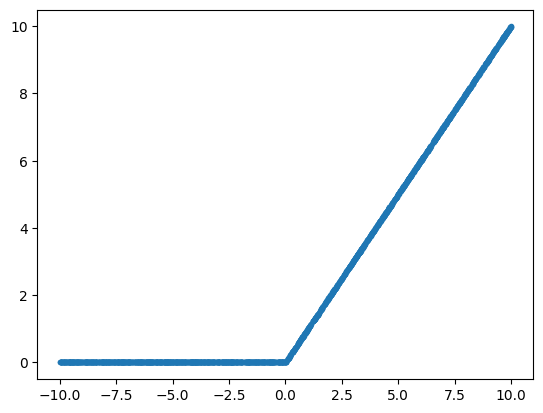

In [5]:
# Vamos a graficar las funciones de activación y modificar los parámetros que las definen
# Encuentran los parámetros en https://keras.io/api/layers/activations/
# Relu
import matplotlib.pyplot as plt
x=np.random.uniform(low=-10.0, high=10, size=(2000,))
y=keras.activations.relu(x, negative_slope=0, max_value=None, threshold=0)
plt.plot(x,y,'.')

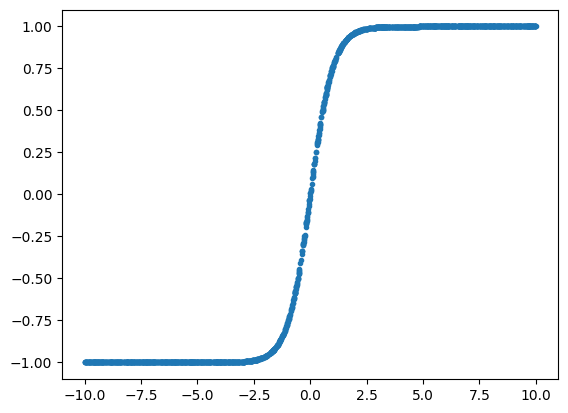

In [6]:
# tanh
y=keras.activations.tanh(x)
plt.plot(x,y,'.')

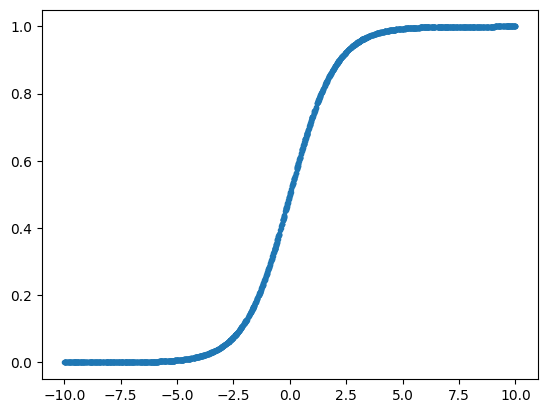

In [7]:
#sigmoid
y=keras.activations.sigmoid(x)
plt.plot(x,y,'.')

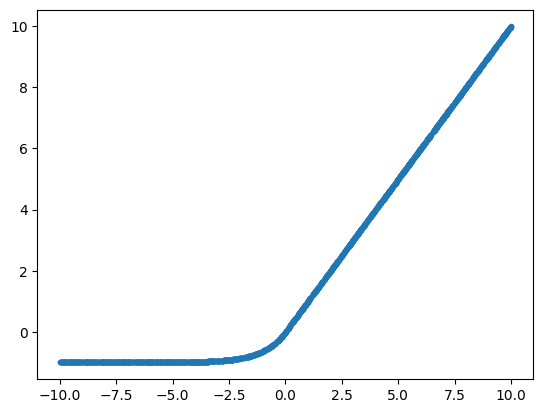

In [8]:
# elu
y=keras.activations.elu(x, alpha=1.0)
plt.plot(x,y,'.')

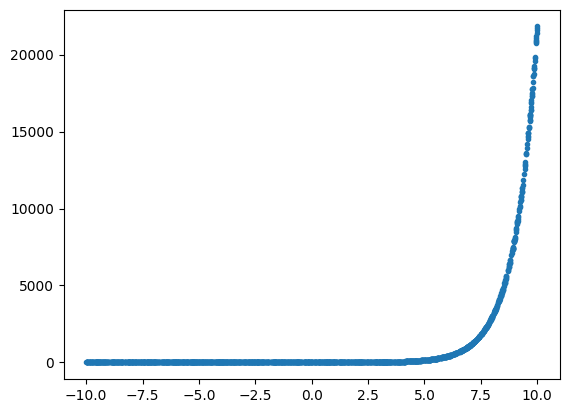

In [9]:
# Exponential
y=keras.activations.exponential(x)
plt.plot(x,y,'.')

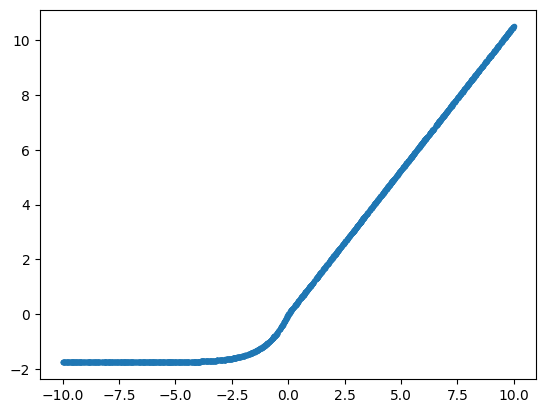

In [10]:
# Selu
y=keras.activations.selu(x)
plt.plot(x,y,'.')

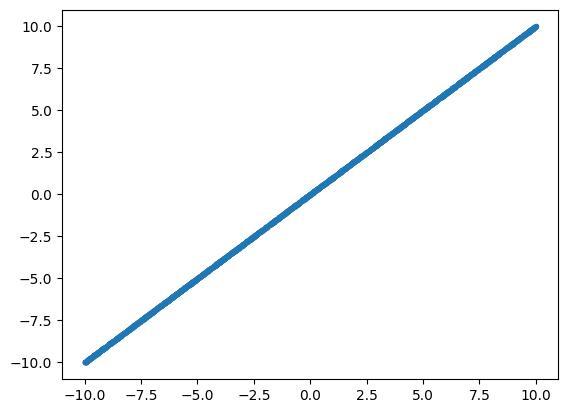

In [11]:
# Linear
y=keras.activations.linear(x)
plt.plot(x,y,'.')

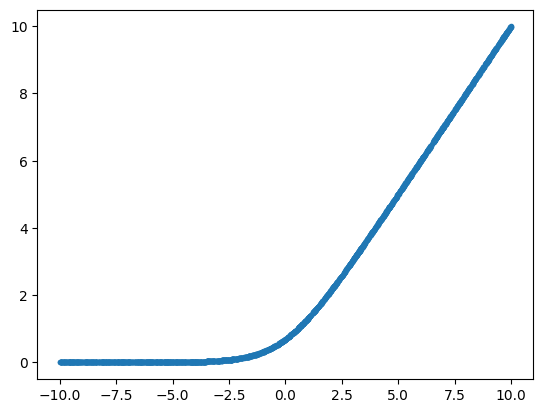

In [12]:
y=keras.activations.softplus(x)
plt.plot(x,y,'.')


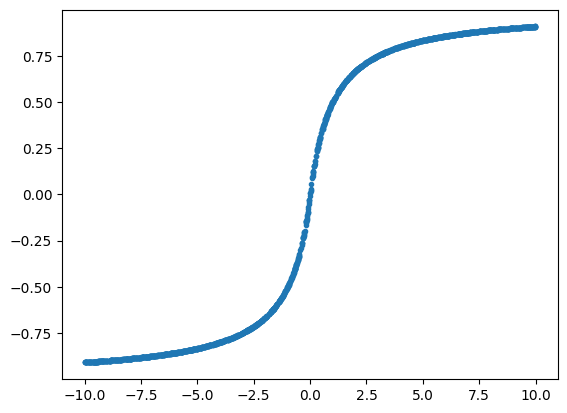

In [13]:
y=keras.activations.softsign(x)
plt.plot(x,y,'.')

# Arquitectura y funcionalidad de la Redes neuronales secuenciales:

De las funciones de activación habladas en la clase anterior podemos advertir dos características que deben poseer una red neuronal:

Las funciones de activación de las capas ocultas deben ser funciones de activación no lineales, con el fín de que la red actue como un aproximador universal a una función.

La función de activación de la capa de salida determina el tipo de clasificación/regresión del problema que se pretende solucionar.
Como regla general, se tiene que la función de activación de las capas ocultas puede ser definida como una función ReLU y, dependiendo del problema, podemos definir la función de activación de la capa de salida como:

- Función de activación sigmoide: si el problema de clasificación es binario.
- Función de activación Softmax: si el problema de clasificación es multiclase.
- Función de activación lineal: si el problema se trata de una regresión.

En resumen, en la siguiente figura se ilustran la arquitectura de red de los problemas que pueden presentarse en la clasificación/regresión usando una red neuronal secuencial y las funciones de activación definidas en las capas que la componen.

In [14]:
# https://github.com/ssanchezgoe/curso_deep_learning_economia/blob/main/NBs_Google_Colab/DL_S08_Problemas_FFNN.ipynb
# https://github.com/ssanchezgoe/curso_deep_learning_economia/blob/main/NBs_Google_Colab/DL_S11_DNN.ipynb

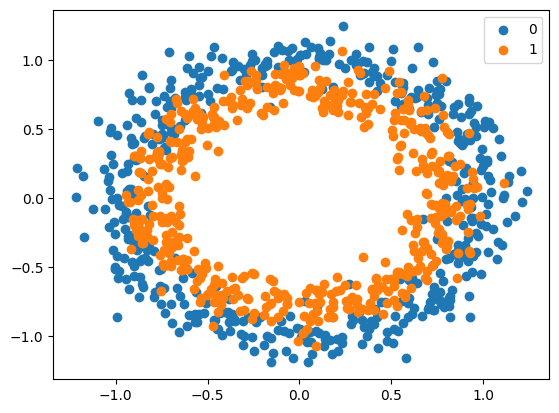

In [15]:
# generación de círculos
# Algunas librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

X, y = make_circles(n_samples=1000, noise=0.1, random_state=1)

plt.scatter(X[np.where((y==0)),0],X[np.where((y==0)),1], label='0')
plt.scatter(X[np.where((y==1)),0],X[np.where((y==1)),1], label='1')
plt.legend()
plt.show()

In [16]:
# Creación del modelo
def build_model2(activation = 'sigmoid', loss='binary_crossentropy'):
  model = keras.models.Sequential()
  model.add(keras.layers.Dense(4, input_dim=2, activation='relu'))
  model.add(keras.layers.Dense(8, activation='relu'))
  model.add(keras.layers.Dense(1, activation = activation))
  opt = keras.optimizers.SGD(learning_rate=0.01)
  model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])
  return model

#https://developers.google.com/machine-learning/crash-course/classification/accuracy#:~:text=Accuracy%20is%20one%20metric%20for,predictions%20Total%20number%20of%20predictions

Epoch 1/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5040 - loss: 0.6980 - val_accuracy: 0.4980 - val_loss: 0.6983
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5140 - loss: 0.6958 - val_accuracy: 0.5220 - val_loss: 0.6960
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5220 - loss: 0.6937 - val_accuracy: 0.5240 - val_loss: 0.6941
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5220 - loss: 0.6921 - val_accuracy: 0.5220 - val_loss: 0.6923
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5060 - loss: 0.6906 - val_accuracy: 0.5060 - val_loss: 0.6909
Epoch 6/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4940 - loss: 0.6893 - val_accuracy: 0.5100 - val_loss: 0.6897
Epoch 7/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4880 - loss: 0.6882 - val_accuracy: 0.5100 - val_loss: 0.6887
Epoch 8/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4900 - loss: 0.6873 - val_accuracy: 0

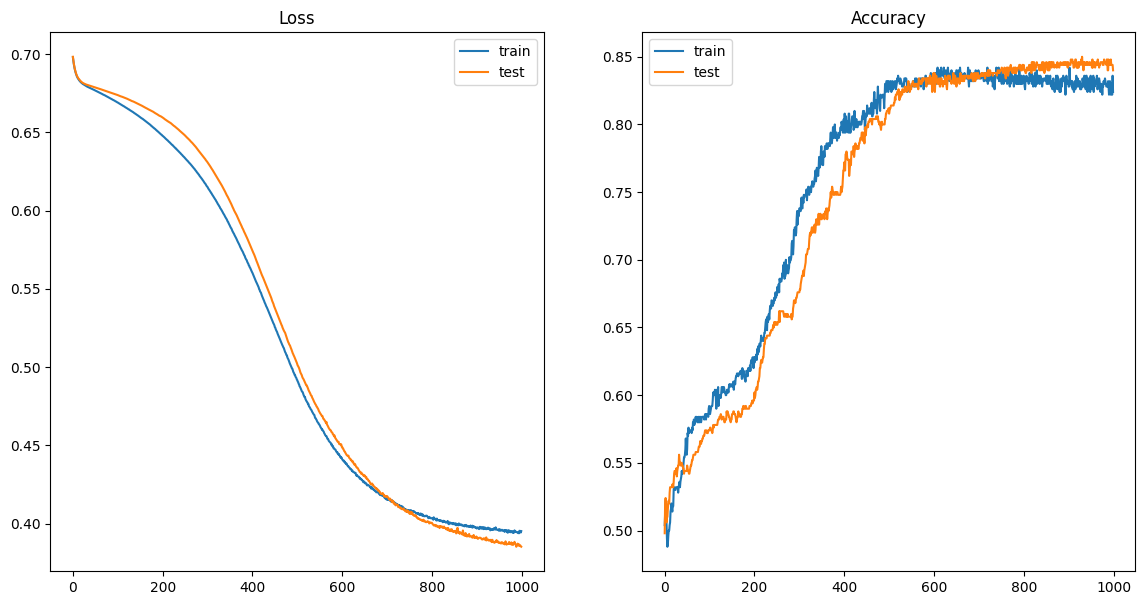

In [ ]:
# binary cross entropy:
keras.backend.clear_session()
# Prerprocesado de los datos
n_train = 500
train_X, test_X = X[:n_train, :], X[n_train:, :]
train_y, test_y = y[:n_train], y[n_train:]
model = build_model2()
history = model.fit(train_X, train_y, validation_data=(test_X, test_y), epochs=1000, verbose=1)
# Evaluación del modelo
_, train_acc = model.evaluate(train_X, train_y, verbose=0)
_, test_acc = model.evaluate(test_X, test_y, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))
# Gráficas:
plt.figure(figsize=(14,7))
# Gráfica de pérdidas durante el entrenamiento
plt.subplot(121)
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
# Gráfica de las precisión durante el entrenamiento
plt.subplot(122)
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show()

# Laboratorio
1. Para el dataset make a moon de sklearn, construir un modelo de una red neuronal con keras para clasificar los datos.

2. Para el dataset load digits, construir un modelo de red neuronal empleando keras para realizar la clasificación.

In [ ]:
# Import the necessary modules
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits


In [ ]:
digits = load_digits(n_class=6)
X, y = digits.data, digits.target
n_samples, n_features = X.shape


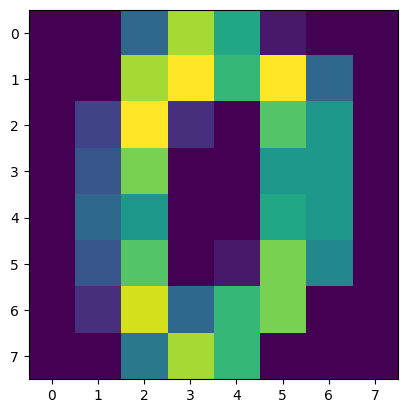

In [ ]:
plt.imshow(X[0].reshape(8, 8))

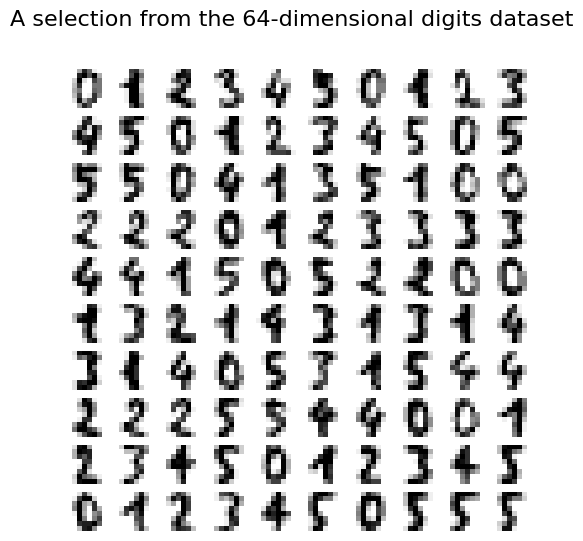

In [ ]:
fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(6, 6))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(X[idx].reshape((8, 8)), cmap=plt.cm.binary)
    ax.axis("off")
_ = fig.suptitle("A selection from the 64-dimensional digits dataset", fontsize=16)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Punto 1 del laboratorio

**Ahora vas a actuar como un profesional en data science con un CI de 137, tu tarea es resolver el siguiente punto: 1. Para el dataset make a moon de sklearn, construir un modelo de una red neuronal con keras para clasificar los datos. Antes de iniciar cualquiero cosa, responde a las siguientes preguntas: -¿Cómo es el dataset de make a moon? -¿Cuales sserían los datos de entrada para la red Neuronal? -¿Cuantas capas serían las optimas para este problema? - En base a lo anterior, ¿Cuantas neuronas debe tener cada capa y cual es la función de activación adecuada? - En la capa final, ¿cual es la función de activación adecuada? - ¿Cual es una buena metrica para medir el modelo?**

¡Excelente iniciativa! Como un profesional en ciencia de datos, es fundamental hacer estas preguntas antes de sumergirnos en el código. Analicemos el problema del dataset make_moons y cómo abordar su clasificación con Keras.

Aquí tienes las respuestas a tus preguntas:

¿Cómo es el dataset de make_moons?

El dataset make_moons de sklearn es un conjunto de datos sintético bidimensional diseñado para problemas de clasificación binaria no linealmente separables. Genera puntos de datos que forman dos "lunas" o semilunas entrelazadas en un espacio 2D. Es decir, los puntos de una clase forman una luna y los puntos de la otra clase forman la otra luna, y estas dos lunas están interconectadas de manera que no se pueden separar con una sola línea recta.
Visualmente, parece una forma similar a dos medialunas o paréntesis enfrentados. Es un excelente dataset para probar la capacidad de un clasificador para encontrar fronteras de decisión complejas.
¿Cuáles serían los datos de entrada para la red Neuronal?

Para este dataset, los datos de entrada (X) para la red neuronal serían las dos coordenadas (X e Y) de cada punto. Es un dataset con 2 características por muestra.
Los datos de salida (y) serían las etiquetas de clase binarias (0 o 1), indicando a cuál de las dos lunas pertenece cada punto.
¿Cuántas capas serían las óptimas para este problema?

Dado que el problema de make_moons es no linealmente separable, una red neuronal necesita al menos una capa oculta para aprender las características no lineales. Sin embargo, para una buena capacidad de modelado de la curva y robustez, dos capas ocultas suelen ser una opción robusta y comúnmente utilizada para este tipo de problemas sintéticos. Una arquitectura con dos capas ocultas permite que la red aprenda representaciones más complejas de los datos.
En base a lo anterior, ¿Cuántas neuronas debe tener cada capa y cuál es la función de activación adecuada?

Capa de Entrada (implícita): Tendrá 2 neuronas (una por cada característica: X e Y). No se le aplica una función de activación directamente; los datos simplemente pasan.
Primera Capa Oculta: Podemos empezar con un número razonable de neuronas, por ejemplo, 16 neuronas. La función de activación adecuada para capas ocultas en problemas no lineales es ReLU (Rectified Linear Unit). Es eficiente computacionalmente y ayuda a mitigar el problema del desvanecimiento del gradiente.
Segunda Capa Oculta: Podemos usar 8 neuronas. También con función de activación ReLU.
En la capa final, ¿cuál es la función de activación adecuada?

Dado que es un problema de clasificación binaria (predecir 0 o 1), la función de activación adecuada para la capa de salida es Sigmoid. Esta función comprime la salida a un valor entre 0 y 1, que puede interpretarse directamente como la probabilidad de pertenecer a la clase positiva (clase 1).
¿Cuál es una buena métrica para medir el modelo?

Para un problema de clasificación binaria con un dataset relativamente equilibrado como make_moons, la precisión (accuracy) es una métrica muy buena y fácilmente interpretable. Nos dirá qué porcentaje de las muestras se clasificaron correctamente.
Adicionalmente, se recomienda monitorear la pérdida (loss) durante el entrenamiento y la validación para asegurar que el modelo está aprendiendo y no sobreajustando o subajustando.

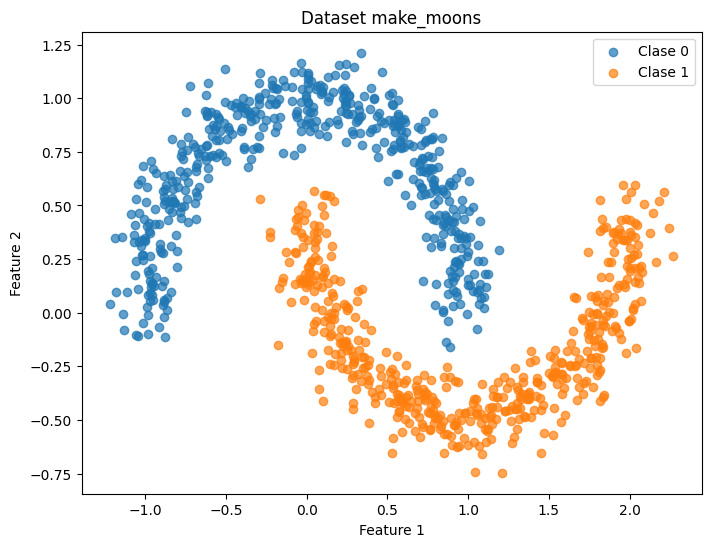

Tamaño del conjunto de entrenamiento: 800 muestras
Tamaño del conjunto de prueba: 200 muestras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3663 - loss: 0.7119 - val_accuracy: 0.5900 - val_loss: 0.6864
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6325 - loss: 0.6727 - val_accuracy: 0.6500 - val_loss: 0.6498
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7188 - loss: 0.5863 - val_accuracy: 0.7050 - val_loss: 0.5316
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7987 - loss: 0.4540 - val_accuracy: 0.7950 - val_loss: 0.4118
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8487 - loss: 0.3635 - val_accuracy: 0.8450 - val_loss: 0.3244
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8750 - loss: 0.3070 - val_accuracy: 0.8700 - val_loss: 0.2755
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8813 - loss: 0.2697 - val_accuracy: 0.9100 - val_loss: 0.2443
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9025 - loss: 0.2444 - val_accuracy: 0.8950 - 

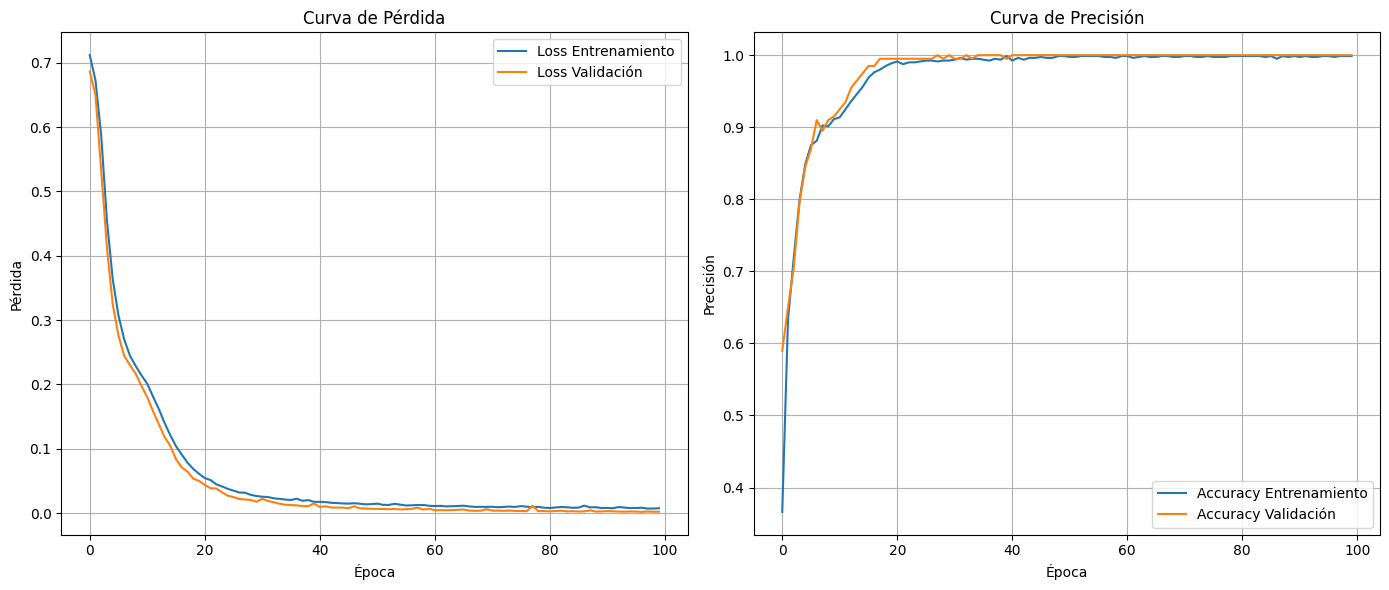

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow import keras

# 1. Cargar el dataset make_moons
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Visualizar el dataset (opcional)
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Clase 0', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Clase 1', alpha=0.7)
plt.title('Dataset make_moons')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# 2. Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño del conjunto de prueba: {X_test.shape[0]} muestras')

# 3. Definir la función para construir el modelo
def build_moon_model():
    model = keras.models.Sequential()
    # Primera capa oculta: 16 neuronas, activación ReLU
    model.add(keras.layers.Dense(4, input_dim=2, activation='relu'))
    # Segunda capa oculta: 8 neuronas, activación ReLU
    model.add(keras.layers.Dense(2, activation='relu'))
    # Capa final: 1 neurona, activación Sigmoide (clasificación binaria)
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # Compilar el modelo
    opt = keras.optimizers.Adam(learning_rate=0.01) # Usamos Adam que suele ser más robusto
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

# Limpiar sesión de Keras antes de construir un nuevo modelo
keras.backend.clear_session()

# Construir el modelo
model_moon = build_moon_model()
model_moon.summary()

# 4. Entrenar el modelo
history = model_moon.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, # Menos epochs inicialmente para evitar sobreajuste rápido
    verbose=1,
    batch_size=32 # Agregamos un batch_size para un entrenamiento más estable
)

# 5. Evaluación del modelo
_, train_acc = model_moon.evaluate(X_train, y_train, verbose=0)
_, test_acc = model_moon.evaluate(X_test, y_test, verbose=0)
print('\n--- Resultados Finales ---')
print(f'Accuracy en datos de entrenamiento: {train_acc:.3f}')
print(f'Accuracy en datos de prueba: {test_acc:.3f}')

# 6. Gráficas de Pérdida y Precisión
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['loss'], label='Loss Entrenamiento')
plt.plot(history.history['val_loss'], label='Loss Validación')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['accuracy'], label='Accuracy Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy Validación')
plt.title('Curva de Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Punto 2

Excelente! Ahora vamos a abordar el segundo punto del laboratorio con el dataset load_digits. Para construir la red neuronal más óptima posible, primero responderé a las preguntas fundamentales, siguiendo la misma lógica que en el ejercicio anterior:

¿Cómo es el dataset de load_digits?

El dataset load_digits de sklearn consiste en imágenes de dígitos escritos a mano. Cada imagen tiene un tamaño de 8x8 píxeles en escala de grises. Esto significa que cada muestra de entrada es un vector de 64 características (8 * 8 = 64 píxeles).
El problema es de clasificación multiclase, ya que el objetivo es identificar a qué dígito pertenece la imagen (del 0 al 9), lo que implica 10 clases distintas.
¿Cuáles serían los datos de entrada para la red Neuronal?

Los datos de entrada (X) para la red neuronal serán los 64 valores de píxeles (características) de cada imagen.
Los datos de salida (y) serán las etiquetas de clase, que representan el dígito (un número entero del 0 al 9).
¿Cuántas capas serían las óptimas para este problema?

Para problemas de clasificación de imágenes, incluso de pequeño tamaño como estas, se suelen requerir capas ocultas para aprender patrones complejos. Una arquitectura con dos o tres capas ocultas puede ser muy efectiva.
En base a lo anterior, ¿Cuántas neuronas debe tener cada capa y cuál es la función de activación adecuada?

Capa de Entrada (implícita): Tendrá 64 neuronas, una por cada característica (píxel).
Primera Capa Oculta: Un número mayor de neuronas, por ejemplo, 128 neuronas. La función de activación adecuada es ReLU por su eficiencia y capacidad para aprender no linealidades.
Segunda Capa Oculta: Una capa con un número intermedio de neuronas, por ejemplo, 64 neuronas. También con función de activación ReLU.
En la capa final, ¿cuál es la función de activación adecuada?

Dado que es un problema de clasificación multiclase con 10 clases, la función de activación adecuada para la capa de salida es Softmax. Esta convertirá las puntuaciones de salida en probabilidades para cada una de las 10 clases, asegurando que sumen 1.
El número de neuronas en la capa de salida debe ser 10 (una por cada clase).
¿Cuál es una buena métrica para medir el modelo?

Para problemas de clasificación multiclase, la precisión (accuracy) es una métrica clave. La pérdida (loss) adecuada para etiquetas enteras (no one-hot encoded) y clasificación multiclase es sparse_categorical_crossentropy.
Ahora, implementaremos este modelo en la celda de código seleccionada. Realizaré los siguientes pasos:

Cargar el dataset load_digits.
Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%).
Normalizar los datos de entrada (generalmente útil para redes neuronales).
Definir la función para construir el modelo de Keras con la arquitectura descrita.
Compilar el modelo con el optimizador Adam, la función de pérdida sparse_categorical_crossentropy y la métrica accuracy.
Entrenar el modelo.
Evaluar el modelo y mostrar la precisión de entrenamiento y prueba.
Graficar la evolución de la pérdida y la precisión durante el entrenamiento.
Parece que hubo un pequeño error de sintaxis en la línea kera's.backend.clear_session(). La apóstrofe está causando que Python interprete la cadena de forma incorrecta. Lo corregiré a keras.backend.clear_session() para que el código se ejecute sin problemas y podamos continuar con el entrenamiento del modelo para el dataset load_digits.

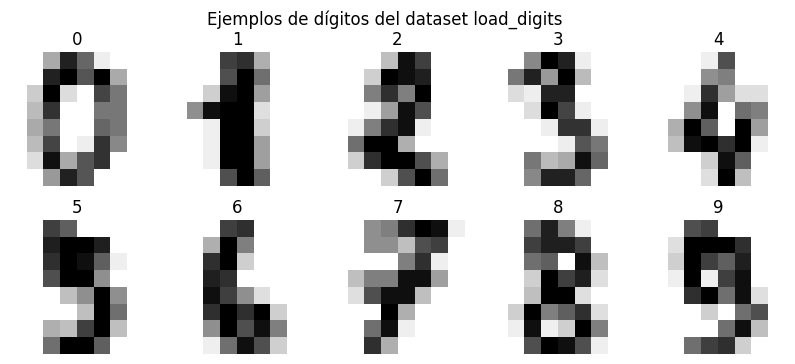

Tamaño del conjunto de entrenamiento: 1437 muestras
Tamaño del conjunto de prueba: 360 muestras
Número de características de entrada: 64
Número de clases de salida: 10


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 606 (2.37 KB)

 Trainable params: 606 (2.37 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1253 - loss: 2.3015 - val_accuracy: 0.1417 - val_loss: 2.2141
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1921 - loss: 2.1665 - val_accuracy: 0.2250 - val_loss: 2.0938
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2533 - loss: 2.0164 - val_accuracy: 0.2639 - val_loss: 1.9459
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2916 - loss: 1.8659 - val_accuracy: 0.3111 - val_loss: 1.7970
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3730 - loss: 1.7192 - val_accuracy: 0.4028 - val_loss: 1.6335
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4495 - loss: 1.5638 - val_accuracy: 0.4778 - val_loss: 1.4597
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5010 - loss: 1.4120 - val_accuracy: 0.5528 - val_loss: 1.3093
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5101 - loss: 1.2893 - val_accuracy: 0.5611 - val_loss:

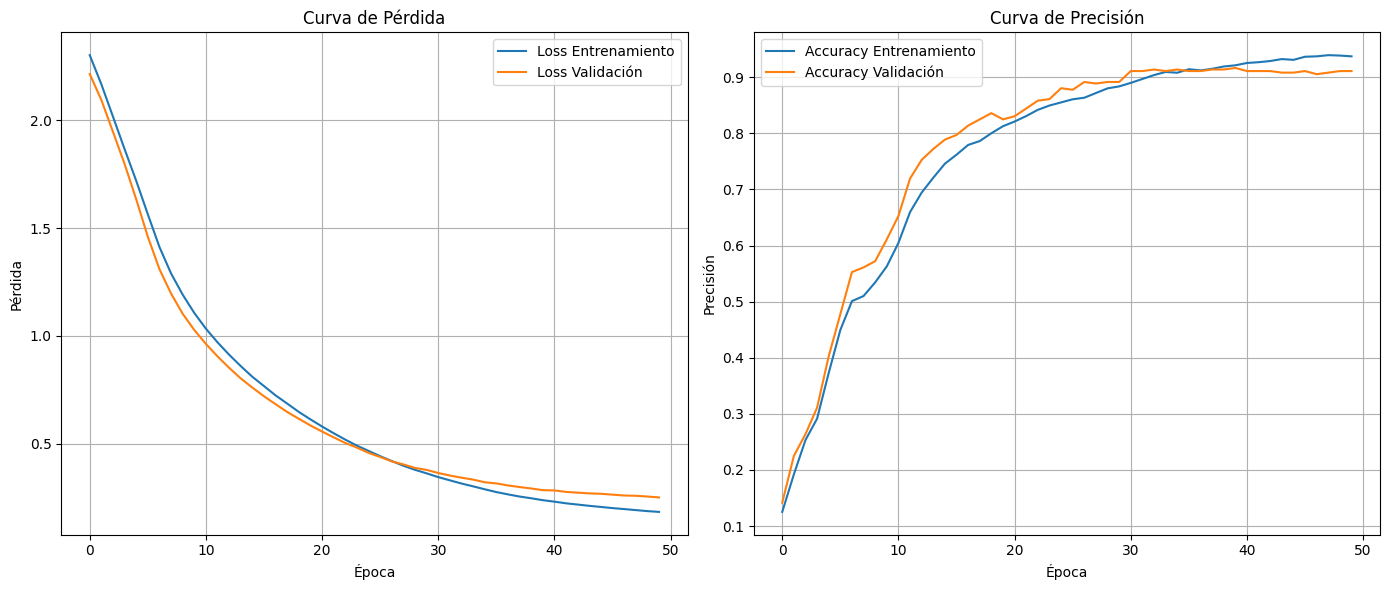

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

# 1. Cargar el dataset load_digits
digits = load_digits()
X, y = digits.data, digits.target

# Normalizar los datos de entrada (escalar los valores de los píxeles a un rango)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualizar algunas imágenes (opcional)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
for ax, image, label in zip(axes.flatten(), digits.images, digits.target):
    ax.imshow(image, cmap=plt.cm.gray_r)
    ax.set_title(label)
    ax.axis('off')
plt.suptitle('Ejemplos de dígitos del dataset load_digits')
plt.show()

# 2. Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño del conjunto de prueba: {X_test.shape[0]} muestras')
print(f'Número de características de entrada: {X_train.shape[1]}')
print(f'Número de clases de salida: {len(np.unique(y))}')

# 3. Definir la función para construir el modelo
def build_digits_model():
    model = keras.models.Sequential([
        keras.Input(shape=(X_train.shape[1],)), # Explicitly define input layer
        # Primera capa oculta: 64 neuronas, activación ReLU
        keras.layers.Dense(8, activation='relu'),
        # Segunda capa oculta: 32 neuronas, activación ReLU
        keras.layers.Dense(4, activation='relu'),
        # Capa final: 10 neuronas (una por cada dígito), activación Softmax
        keras.layers.Dense(len(np.unique(y)), activation='softmax')
    ])

    # Compilar el modelo
    opt = keras.optimizers.Adam(learning_rate=0.001) # Un learning rate común para Adam
    model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

# Limpiar sesión de Keras antes de construir un nuevo modelo
keras.backend.clear_session()

# Construir el modelo
model_digits = build_digits_model()
model_digits.summary()

# 4. Entrenar el modelo
history = model_digits.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50, # Ajustar las epochs según sea necesario, 50 es un buen comienzo
    verbose=1,
    batch_size=32 # Tamaño de lote común
)

# 5. Evaluación del modelo
_, train_acc = model_digits.evaluate(X_train, y_train, verbose=0)
_, test_acc = model_digits.evaluate(X_test, y_test, verbose=0)
print('\n--- Resultados Finales ---')
print(f'Accuracy en datos de entrenamiento: {train_acc:.3f}')
print(f'Accuracy en datos de prueba: {test_acc:.3f}')

# 6. Gráficas de Pérdida y Precisión
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['loss'], label='Loss Entrenamiento')
plt.plot(history.history['val_loss'], label='Loss Validación')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['accuracy'], label='Accuracy Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy Validación')
plt.title('Curva de Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Interacción con el agente para comprender mejor

**Eres un excelente profesor de ciencia de datos con un CI de 145, este notebook habla sobre keras y las distintas funciones de activación, explicame el contenido en texto del notebook de una manera más sencillas, incluyendo ejemplos fáciles para relacionar conceptos y ejemplos de aplicación**

¡Claro que sí! Con gusto te explico el contenido de este notebook de una manera sencilla y con ejemplos prácticos. Piensa en las redes neuronales como un cerebro artificial que aprende de los datos.

¿Qué es Keras?
Imagina que quieres construir un auto muy complejo. Keras es como un kit de LEGO avanzado para construir ese auto. Te proporciona piezas (llamadas 'capas') que ya están hechas y que puedes unir fácilmente para crear tu 'coche' (tu red neuronal). No necesitas preocuparte por cómo se fabrican las piezas, solo por cómo encajarlas para que el auto funcione bien. Keras hace que sea muy fácil y rápido diseñar y entrenar modelos de aprendizaje profundo.

Las funciones de activación: El 'cerebro' de la neurona
Dentro de cada pieza de LEGO (cada neurona) de nuestro coche, hay un pequeño interruptor o un 'decisor' que se llama función de activación. Su trabajo es decidir si esa neurona debe 'activarse' y pasar su información a la siguiente neurona, y cómo de fuerte debe ser esa señal.

¿Por qué las necesitamos? Sin estas funciones, nuestra red neuronal solo podría aprender relaciones directas y sencillas (como una línea recta). Con ellas, la red puede aprender patrones mucho más complejos y no lineales, como curvas o formas en zigzag, que son esenciales para entender el mundo real.

Aquí te explico las más importantes:

Lineal:

¿Qué hace? Esta es la más simple. ¡No hace casi nada! Lo que entra, sale igual. Es como un cable directo. Si le das un 5, te devuelve un 5. Si le das -2, te devuelve -2.
Ejemplo: Imagina un espejo. Refleja exactamente lo que ve. No cambia la imagen.
Aplicación: Se usa principalmente en la capa de entrada de una red (donde entran los datos por primera vez) o a veces en la capa de salida para problemas de regresión (cuando quieres predecir un número continuo, como el precio de una casa).
Sigmoide (o Logística):

¿Qué hace? Transforma cualquier número (positivo o negativo, grande o pequeño) en un valor entre 0 y 1. Tiene forma de 'S'.
Ejemplo: Piensa en un termómetro que mide la 'probabilidad' de algo. Si la temperatura sube mucho (número positivo grande), el termómetro se acerca a 1 (100% de probabilidad). Si baja mucho (número negativo grande), se acerca a 0 (0% de probabilidad). Valores intermedios dan probabilidades entre 0 y 1.
Ventaja: Ideal para problemas donde quieres una probabilidad de 'sí' o 'no'.
Desventaja: Puede tener problemas si los números son muy grandes o muy pequeños, ya que la 'S' se vuelve muy plana en los extremos, lo que dificulta el aprendizaje.
Aplicación: Principalmente en la capa de salida para problemas de clasificación binaria (por ejemplo, ¿es un gato o no es un gato?).
Tangente Hiperbólica (Tanh):

¿Qué hace? Muy parecida a la sigmoide, pero transforma los números en valores entre -1 y 1. También tiene forma de 'S'.
Ejemplo: Es como la sigmoide, pero en lugar de ir de 'apagado' (0) a 'encendido' (1), va de 'muy negativo' (-1) a 'muy positivo' (1), pasando por el 'punto neutro' (0).
Ventaja: Al tener valores negativos y positivos, puede ser más eficiente para algunas capas internas de la red.
Aplicación: A menudo en capas ocultas (las capas intermedias de la red).
ReLU (Rectified Linear Unit):

¿Qué hace? Es muy sencilla pero muy potente: si el número de entrada es negativo, devuelve 0. Si es positivo, devuelve el mismo número. Es decir, max(0, x).
Ejemplo: Imagina un grifo que solo deja pasar agua si la presión es positiva. Si la presión es negativa (chupa el agua), el grifo se cierra (0). Si la presión es positiva, el grifo se abre y sale el agua con esa misma presión.
Ventajas: Es súper rápida de calcular y ayuda a que las redes neuronales aprendan más eficazmente, evitando el problema de la 'desaparición del gradiente' (que es como si la señal se atenuara demasiado y la red dejara de aprender).
Desventaja: Si la entrada siempre es negativa, la neurona puede 'morir' (siempre devolverá 0 y dejará de aprender).
Aplicación: Es la función de activación más popular y se usa muchísimo en las capas ocultas de casi todas las redes neuronales modernas.
Softmax:

¿Qué hace? Esta es para situaciones donde tienes varias opciones y quieres saber la probabilidad de cada una, y que todas las probabilidades sumen 1 (100%).
Ejemplo: Imagina que tienes una foto y quieres saber si es un perro, un gato o un pájaro. Softmax te diría: "Es 70% perro, 20% gato, 10% pájaro". Fíjate que 70+20+10 = 100%. Te da una distribución de probabilidad para todas las clases posibles.
Aplicación: Exclusivamente en la capa de salida para problemas de clasificación multiclase (cuando quieres clasificar en más de dos categorías).
¿Cómo construir tu red neuronal con estas funciones?
La clave está en la combinación adecuada:

Capas Ocultas: Casi siempre usarás ReLU (o alguna de sus variantes) porque son eficientes y ayudan al aprendizaje de patrones complejos.
Capa de Salida: Aquí es donde decides el tipo de problema:
Clasificación Binaria (¿sí o no?): Usa Sigmoide.
Clasificación Multiclase (¿perro, gato o pájaro?): Usa Softmax.
Regresión (predecir un número): Usa Lineal.
En resumen, Keras te da las herramientas y las funciones de activación son los interruptores inteligentes dentro de tus neuronas que permiten a tu red aprender cosas increíbles, desde reconocer imágenes hasta predecir tendencias. ¡Espero que esta explicación te sea útil para entender mejor el laboratorio!

**Please explain this code:**

¡Claro! Con gusto te explico el código en la celda seleccionada. Este fragmento de código demuestra una de las formas de construir un modelo de red neuronal secuencial en Keras, especificando las funciones de activación para sus capas. En este caso, se usan las funciones de activación 'relu' y 'tanh' mediante capas explícitas de keras.layers.Activation.


**que es esa primera linea de keras.layers.dense()?**

¡Excelente pregunta! La línea keras.layers.Dense(32, input_shape=(16,)) es una de las piezas fundamentales para construir tu red neuronal en Keras. Vamos a desglosarla:

keras.layers.Dense: Esto define una capa densa o capa completamente conectada. Imagina que tienes una fila de neuronas (la capa anterior) y cada neurona de esa fila está conectada a todas las neuronas de la siguiente fila. Por eso se llama 'densa' o 'completamente conectada'. Es el tipo de capa más común en las redes neuronales estándar.

32: Este es el primer argumento y representa el número de neuronas (o unidades) que tendrá esta capa Dense. En este caso, la capa tendrá 32 neuronas. Cuantas más neuronas, más capacidad tiene la capa para aprender patrones complejos, pero también más cálculos y más riesgo de sobreajuste si no se maneja bien.

input_shape=(16,): Este argumento se usa solo en la primera capa de tu modelo (la capa de entrada) para decirle a Keras cómo se verán tus datos de entrada. En este ejemplo, (16,) significa que cada dato de entrada que le pases a la red será un vector o arreglo con 16 características o valores. Keras usará esta información para construir la primera conexión entre los datos de entrada y las 32 neuronas de esta capa Dense.

Ejemplo: Si estuvieras entrenando una red para predecir si un cliente comprará un producto basándote en 16 características (edad, ingresos, número de compras anteriores, etc.), cada cliente sería un dato de entrada con input_shape=(16,).
En resumen, esta línea está creando la primera capa 'oculta' de tu red neuronal, que tiene 32 neuronas, y le estás diciendo que los datos que le llegarán tendrán 16 características. Es como establecer el tamaño de la primera "sala de procesamiento" de tu "cerebro artificial" y cuántas "entradas" tendrá esa sala.

**Please explain this code:**

¡Claro! Con gusto te explico el código de la celda seleccionada, que define una función para construir un modelo de red neuronal en Keras.

Esta celda contiene una función llamada build_model2 que nos permite crear un modelo de red neuronal de forma modular, lo que es muy útil para experimentar con diferentes configuraciones. Aquí te detallo cada parte:

def build_model2(activation = 'sigmoid', loss='binary_crossentropy'):

Define una función que construirá y devolverá un modelo de Keras. Tiene dos parámetros con valores predeterminados:
activation='sigmoid': Será la función de activación de la última capa del modelo. Por defecto, usa 'sigmoid', que es común para clasificación binaria.
loss='binary_crossentropy': Es la función de pérdida que el modelo intentará minimizar durante el entrenamiento. 'binary_crossentropy' es adecuada para problemas de clasificación binaria (como el problema de los círculos que se resuelve más adelante en el notebook).
model = keras.models.Sequential()

Esta línea inicializa un modelo secuencial de Keras. Un modelo Sequential es una pila lineal de capas, lo que significa que la salida de una capa alimenta la entrada de la siguiente. Es la forma más sencilla de construir redes neuronales en Keras.
model.add(keras.layers.Dense(4, input_dim=2, activation='relu'))

Esta es la primera capa oculta del modelo.
keras.layers.Dense: Es una capa completamente conectada, lo que significa que cada neurona de esta capa está conectada a todas las neuronas de la capa anterior (o en este caso, a las entradas).
4: Indica que esta capa tendrá 4 neuronas.
input_dim=2: Solo en la primera capa, esto especifica que la entrada a la red tendrá 2 características. En el ejemplo de make_circles, cada punto (x, y) tiene 2 coordenadas, por lo que es un input_dim=2.
activation='relu': Aplica la función de activación ReLU a la salida de estas 4 neuronas. Como te expliqué antes, ReLU es muy popular para capas ocultas por su eficiencia.
model.add(keras.layers.Dense(8, activation='relu'))

Esta es la segunda capa oculta.
8: Tendrá 8 neuronas.
activation='relu': También usa la función de activación ReLU.
No necesita input_dim porque Keras infiere la forma de entrada de la capa anterior (que es 4, la cantidad de neuronas de la primera capa Dense).
model.add(keras.layers.Dense(1, activation = activation))

Esta es la capa de salida del modelo.
1: Tiene 1 neurona, lo cual es típico para problemas de clasificación binaria (donde la salida es 0 o 1).
activation = activation: Usa la función de activación que se pasó como argumento a la función build_model2 (por defecto, 'sigmoid').
opt = keras.optimizers.SGD(learning_rate=0.01)

Crea una instancia del optimizador SGD (Stochastic Gradient Descent). El optimizador es el algoritmo que ajustará los pesos de la red durante el entrenamiento para minimizar la función de pérdida.
learning_rate=0.01: Es la tasa de aprendizaje, un hiperparámetro que controla qué tan grandes serán los pasos que el optimizador dará para ajustar los pesos. Un learning_rate adecuado es crucial para un buen entrenamiento.
model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])

Compila el modelo. Este paso prepara el modelo para el entrenamiento. Le decimos:
loss=loss: Qué función de pérdida usar (la que se pasó como argumento, por defecto 'binary_crossentropy').
optimizer=opt: Qué optimizador usar (el SGD que acabamos de definir).
metrics=['accuracy']: Qué métricas queremos monitorear durante el entrenamiento y la evaluación (en este caso, la precisión).
return model

Finalmente, la función devuelve el modelo de Keras que acabamos de construir y compilar.
En resumen, esta función build_model2 crea una pequeña red neuronal con dos capas ocultas (ReLU) y una capa de salida (por defecto Sigmoid), configurada para un problema de clasificación binaria. Es una plantilla reutilizable para construir y probar modelos rápidamente.

**Please explain this code:**


¡Claro! Con gusto te explico el código de la celda seleccionada.

Este código es el que lleva a cabo el entrenamiento, evaluación y visualización de los resultados de la red neuronal que definimos con la función build_model2.

Vamos a desglosarlo:

keras.backend.clear_session():

Esta línea es una buena práctica en Keras. Se utiliza para limpiar el gráfico computacional de TensorFlow (el 'backend' de Keras). Si has creado y entrenado varios modelos seguidos, esto ayuda a evitar conflictos y a liberar memoria, asegurando que cada nuevo modelo se inicialice en un estado limpio.
Preprocesado y División de Datos (n_train, train_X, test_X, train_y, test_y ):

n_train = 500: Define que usaremos 500 muestras para el entrenamiento.
train_X, test_X = X[:n_train, :], X[n_train:, :]:
Aquí se dividen los datos de entrada (X) en conjuntos de entrenamiento (train_X) y prueba (test_X).
X[:n_train, :] toma las primeras n_train (500) filas de X y todas sus columnas para el entrenamiento.
X[n_train:, :] toma el resto de las filas de X y todas sus columnas para la prueba.
train_y, test_y = y[:n_train], y[n_train:]:
De manera similar, se dividen las etiquetas (y) en conjuntos de entrenamiento (train_y) y prueba (test_y). Es crucial que las divisiones de X e y correspondan.
Creación y Entrenamiento del Modelo (model, history):

model = build_model2(): Llama a la función build_model2 (que te expliqué en la celda anterior) para construir y compilar la red neuronal. Por defecto, esta función crea un modelo con activación sigmoide en la capa de salida y binary_crossentropy como función de pérdida, ideal para el problema de clasificación de círculos.
history = model.fit(train_X, train_y, validation_data=(test_X, test_y), epochs=1000, verbose=1):
Esta es la parte central del entrenamiento del modelo.
model.fit(): Es el método que entrena la red neuronal.
train_X, train_y: Son los datos de entrada y las etiquetas para el entrenamiento.
validation_data=(test_X, test_y): Le dice a Keras que evalúe el rendimiento del modelo en estos datos de prueba después de cada 'epoch' (ciclo completo de entrenamiento sobre todos los datos de entrenamiento). Esto es útil para detectar el sobreajuste (overfitting).
epochs=1000: El modelo se entrenará durante 1000 ciclos. En cada ciclo, se ajustan los pesos de la red usando los datos de entrenamiento.
verbose=1: Muestra una barra de progreso para cada 'epoch', así como la pérdida y la precisión en los conjuntos de entrenamiento y validación.
history: Un objeto que almacena el historial de entrenamiento (pérdida, precisión) para los conjuntos de entrenamiento y validación a lo largo de las 'epochs'.
Evaluación del Modelo (train_acc, test_acc):

_, train_acc = model.evaluate(train_X, train_y, verbose=0):
model.evaluate(): Calcula la pérdida y las métricas (en este caso, la precisión) del modelo en un conjunto de datos dado.
Aquí se evalúa el rendimiento en el conjunto de entrenamiento. verbose=0 significa que no se imprimirá la salida detallada durante la evaluación.
train_acc almacena la precisión del modelo en los datos de entrenamiento.
_, test_acc = model.evaluate(test_X, test_y, verbose=0):
De forma similar, se evalúa el rendimiento en el conjunto de prueba (test_X, test_y).
test_acc almacena la precisión del modelo en los datos de prueba, lo cual es una medida más objetiva de cómo generaliza el modelo a datos que no ha visto antes.
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc)): Imprime las precisiones obtenidas para los conjuntos de entrenamiento y prueba, formateadas a tres decimales.
Gráficas de Pérdida y Precisión (matplotlib.pyplot):

Este bloque de código utiliza la librería matplotlib para visualizar cómo cambiaron la pérdida y la precisión durante el entrenamiento.
plt.figure(figsize=(14,7)): Crea una figura para las gráficas con un tamaño específico.
plt.subplot(121): Crea un subgráfico en una cuadrícula de 1 fila, 2 columnas, y selecciona la primera posición. Esta será para la pérdida.
plt.title('Loss'): Establece el título del subgráfico.
plt.plot(history.history['loss'], label='train'): Grafica la pérdida del conjunto de entrenamiento a lo largo de las 'epochs'. La información se obtiene del objeto history.
plt.plot(history.history['val_loss'], label='test'): Grafica la pérdida del conjunto de prueba (validación).
plt.legend(): Muestra la leyenda para identificar qué línea corresponde a 'train' y cuál a 'test'.
plt.subplot(122): Selecciona la segunda posición para el subgráfico, que será para la precisión.
De manera similar, se grafica la precisión de entrenamiento (history.history['accuracy']) y la precisión de validación (history.history['val_accuracy']).
plt.show(): Muestra las gráficas generadas.
En resumen, esta celda se encarga de todo el ciclo de vida del entrenamiento de un modelo de red neuronal: preparación de datos, construcción (usando la función build_model2), entrenamiento iterativo, evaluación final y, muy importante, la visualización del proceso de aprendizaje para entender su rendimiento.